In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt



In [4]:

DATA_DIR = Path("TUTORIAL_ROUND_1")

# Load all CSVs in TUTORIAL_ROUND_1 into one DataFrame.
# IMC tutorial data is semicolon-delimited.
files = sorted(DATA_DIR.glob("*.csv"))
frames = [pd.read_csv(f, sep=";").assign(source_file=f.name) for f in files]

df = pd.concat(frames, ignore_index=True)
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_3,mid_price,profit_and_loss,source_file,buyer,seller,symbol,currency,price,quantity
0,-1.0,0,TOMATOES,4999.0,5.0,4998.0,15.0,NaN,NaN,5013.0,...,NaN,5006.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.0,0,EMERALDS,9992.0,14.0,9990.0,29.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.0,100,EMERALDS,9992.0,11.0,9990.0,22.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,-1.0,100,TOMATOES,5000.0,8.0,4998.0,21.0,NaN,NaN,5013.0,...,NaN,5006.5,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,-1.0,200,EMERALDS,9992.0,15.0,9990.0,20.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN


length : 41219

In [5]:
df.columns.tolist()


['day',
 'timestamp',
 'product',
 'bid_price_1',
 'bid_volume_1',
 'bid_price_2',
 'bid_volume_2',
 'bid_price_3',
 'bid_volume_3',
 'ask_price_1',
 'ask_volume_1',
 'ask_price_2',
 'ask_volume_2',
 'ask_price_3',
 'ask_volume_3',
 'mid_price',
 'profit_and_loss',
 'source_file',
 'buyer',
 'seller',
 'symbol',
 'currency',
 'price',
 'quantity']

signals to explore

In [18]:

df = df.sort_values(["product", "timestamp"]).reset_index(drop=True)
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]

df[volume_cols] = df[volume_cols].fillna(0)
# Spread
df["spread"] = df["ask_price_1"] - df["bid_price_1"]

# Depth
df["bid_depth"] = df["bid_volume_1"] + df["bid_volume_2"] + df["bid_volume_3"]
df["ask_depth"] = df["ask_volume_1"] + df["ask_volume_2"] + df["ask_volume_3"]

# Imbalance
df["imbalance"] = (df["bid_depth"] - df["ask_depth"]) / (df["bid_depth"] + df["ask_depth"])

# Mid-price returns
df["mid_return"] = df.groupby("product")["mid_price"].diff()

# Rolling volatility (window=50 ticks)
df["volatility"] = df.groupby("product")["mid_return"].rolling(50).std().reset_index(level=0, drop=True)

# Microprice
df["microprice"] = (
    df["bid_price_1"] * df["ask_volume_1"] +
    df["ask_price_1"] * df["bid_volume_1"]
) / (df["bid_volume_1"] + df["ask_volume_1"])

In [19]:
# separate tomatoes + emeralds
tom = df[df["product"] == "TOMATOES"]
eme = df[df["product"] == "EMERALDS"]
def plot_series(data, column, title):
    plt.figure(figsize=(12,4))
    plt.plot(data["timestamp"], data[column])
    plt.title(title)
    plt.xlabel("timestamp")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()



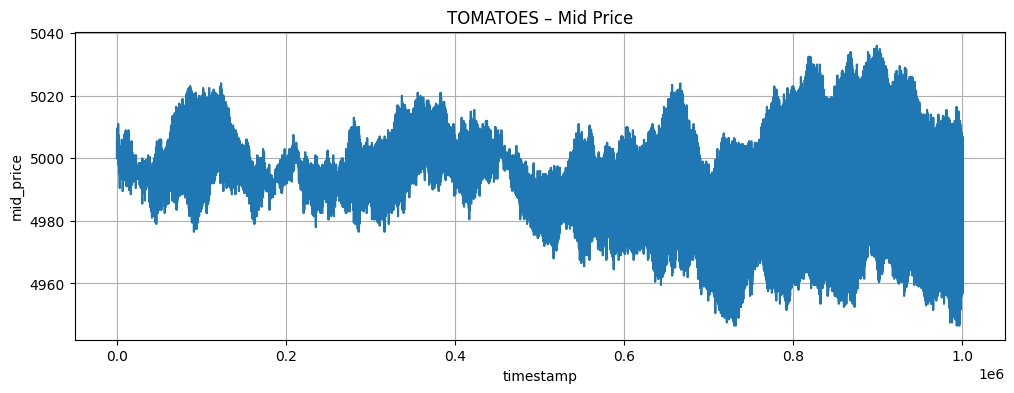

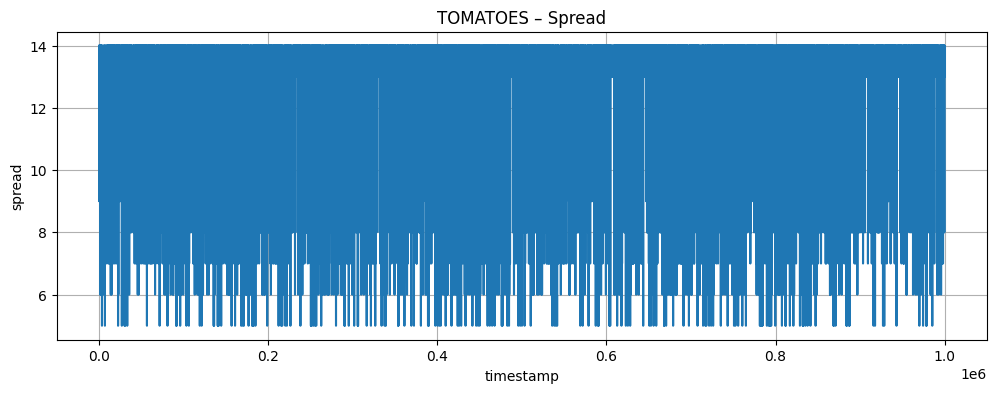

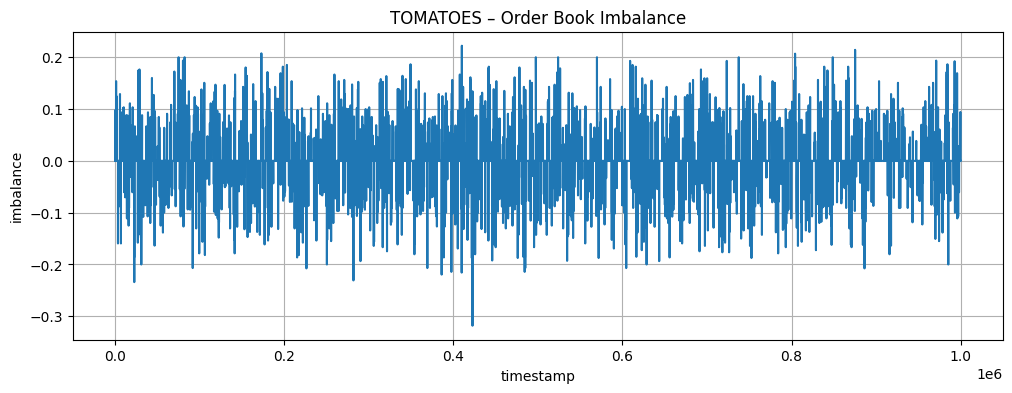

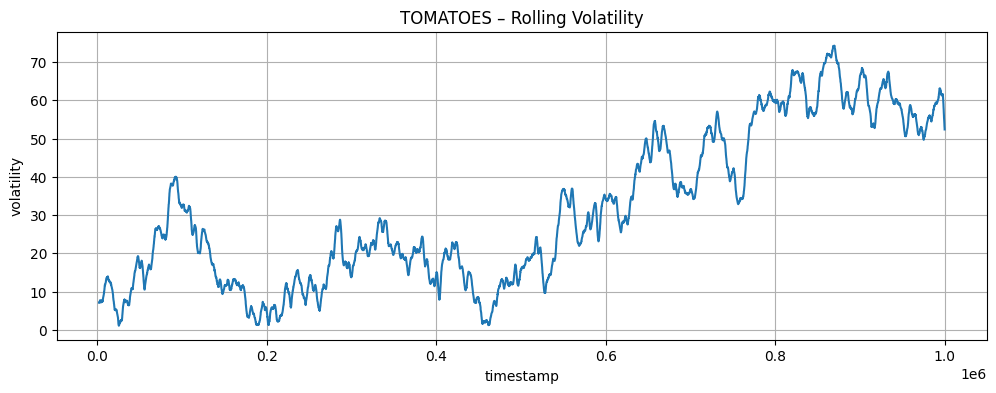

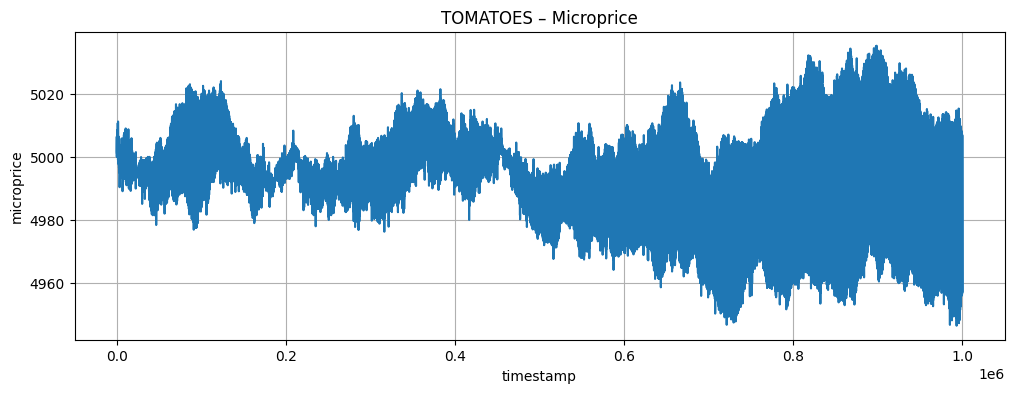

In [20]:
plot_series(tom, "mid_price", "TOMATOES – Mid Price")
plot_series(tom, "spread", "TOMATOES – Spread")
plot_series(tom, "imbalance", "TOMATOES – Order Book Imbalance")
plot_series(tom, "volatility", "TOMATOES – Rolling Volatility")
plot_series(tom, "microprice", "TOMATOES – Microprice")


In [21]:
tom["imbalance"].head()

20000    0.000000
20001    0.000000
20002    0.000000
20003    0.098039
20004    0.000000
Name: imbalance, dtype: float64

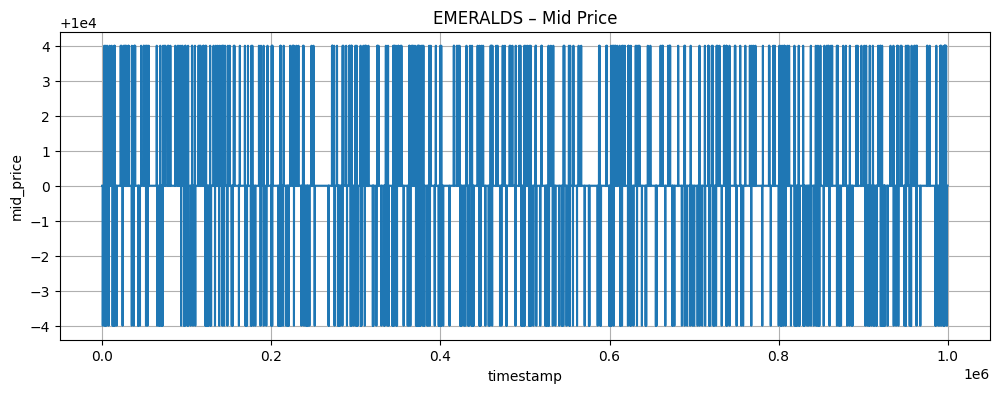

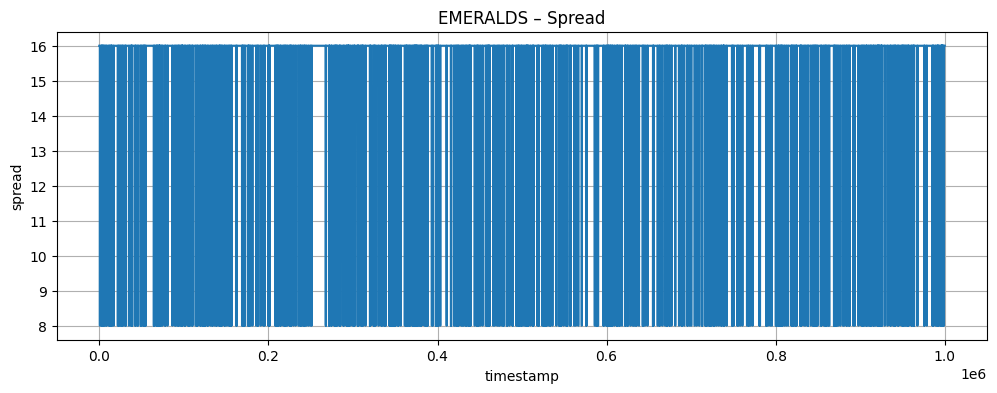

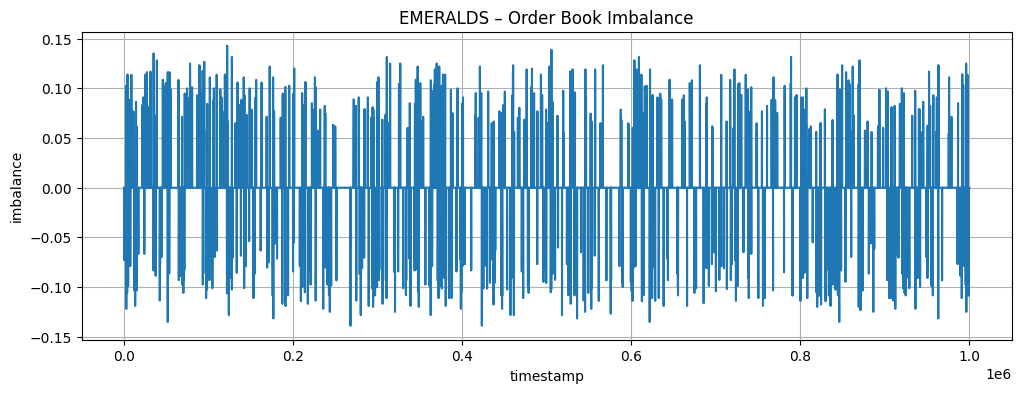

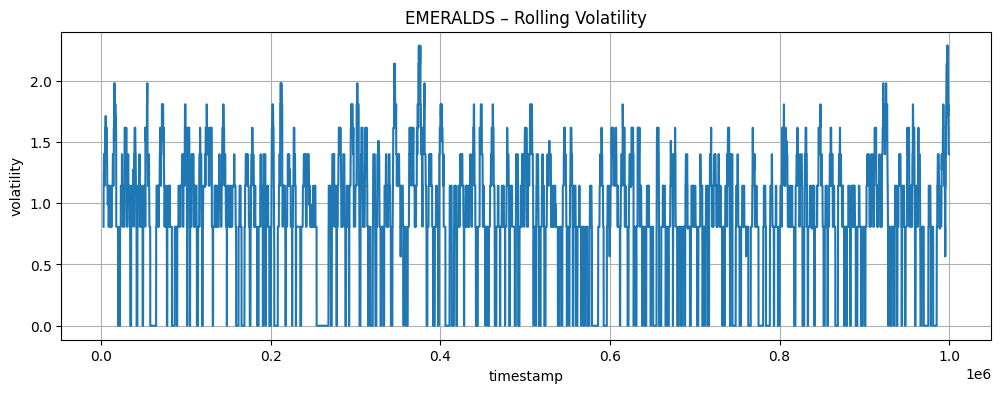

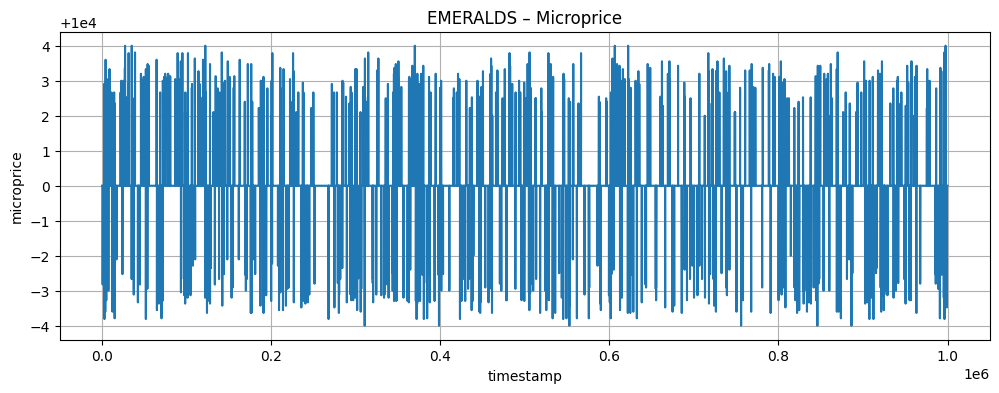

In [22]:
plot_series(eme, "mid_price", "EMERALDS – Mid Price")
plot_series(eme, "spread", "EMERALDS – Spread")
plot_series(eme, "imbalance", "EMERALDS – Order Book Imbalance")
plot_series(eme, "volatility", "EMERALDS – Rolling Volatility")
plot_series(eme, "microprice", "EMERALDS – Microprice")


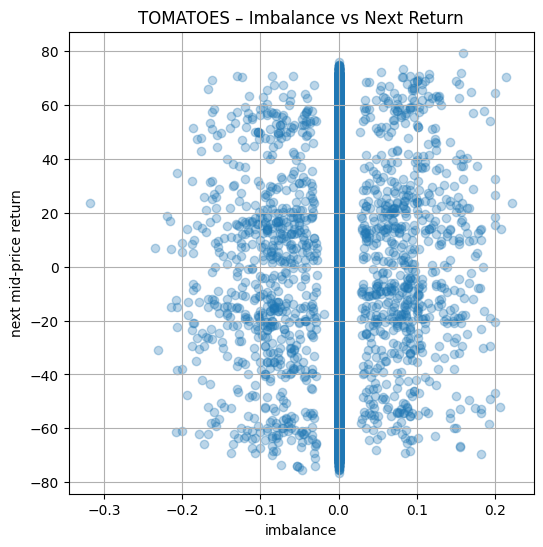

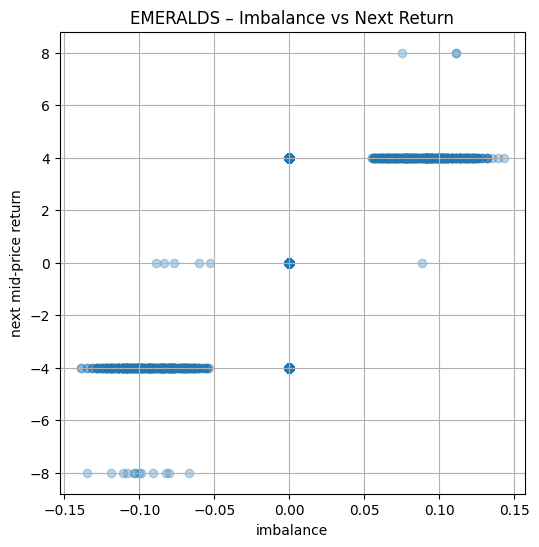

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(tom["imbalance"], tom["mid_return"], alpha=0.3)
plt.title("TOMATOES – Imbalance vs Next Return")
plt.xlabel("imbalance")
plt.ylabel("next mid-price return")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(eme["imbalance"], eme["mid_return"], alpha=0.3)
plt.title("EMERALDS – Imbalance vs Next Return")
plt.xlabel("imbalance")
plt.ylabel("next mid-price return")
plt.grid(True)
plt.show()
